In [40]:
import numpy as np
import sep
import astropy.io.fits as fits

In [41]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [42]:
file_name = fits.open("final_read.fits")
data = fits.getdata("final_read.fits")

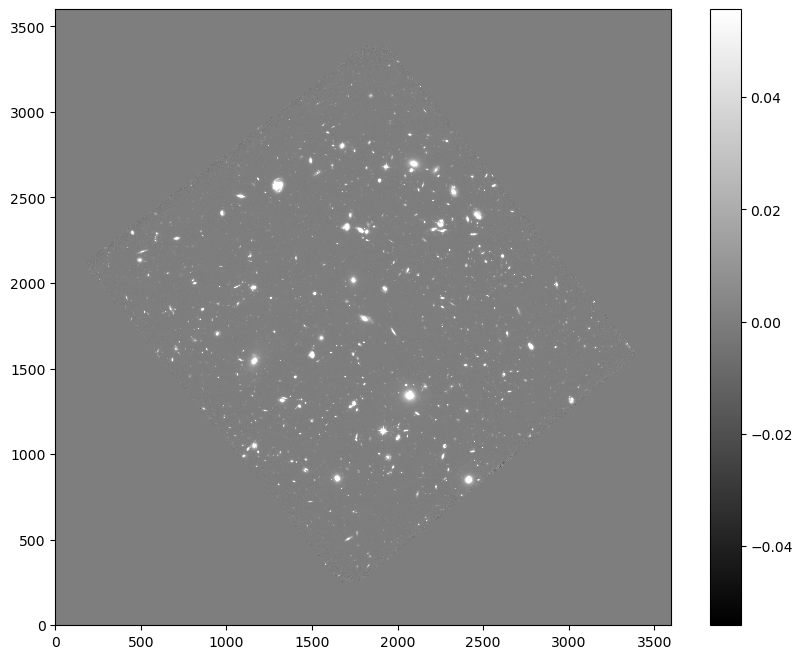

In [43]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation = 'nearest', cmap = 'gray', vmin= m-s, vmax = m+s, origin = 'lower')
plt.colorbar();

In [44]:
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data, bw = 64, bh = 64, fw = 3, fh = 3)
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [45]:
bkg_image = bkg.back()

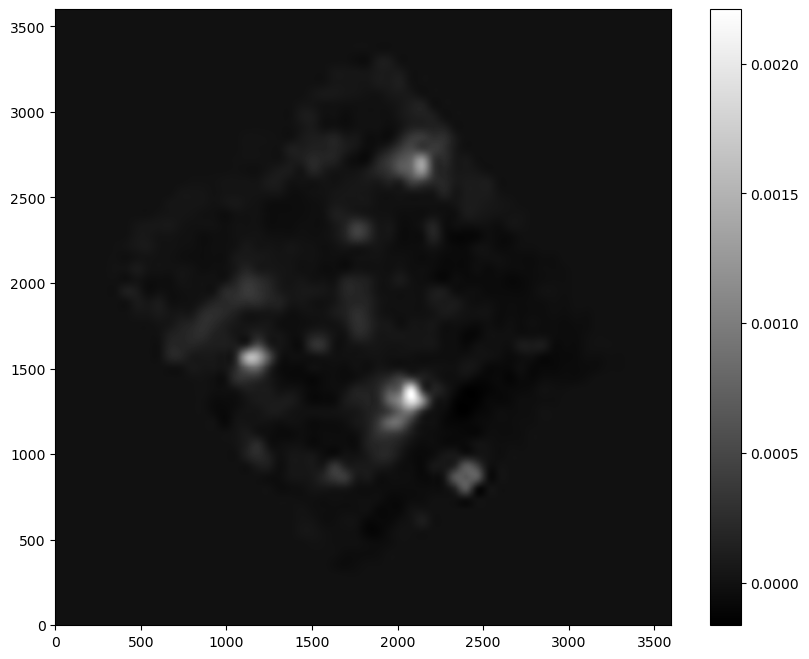

In [46]:
plt.imshow(bkg_image, interpolation = 'nearest', cmap = 'gray', origin = 'lower')
plt.colorbar();

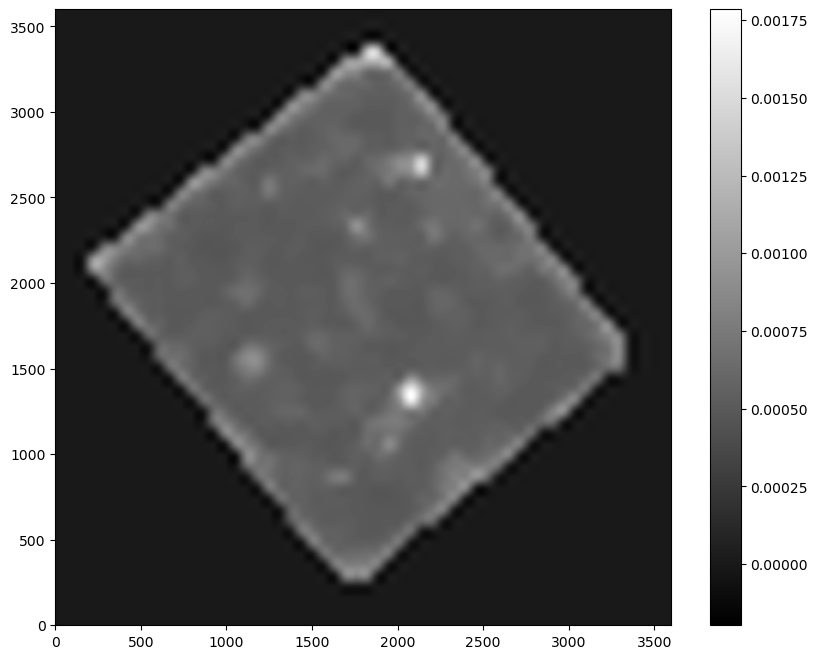

In [47]:
bkg_rms = bkg.rms()
plt.imshow(bkg_rms, interpolation = 'nearest', cmap='gray', origin = 'lower')
plt.colorbar();

In [48]:
data_sub = data - bkg

0.0007716763 0.05486398
Amount of objects:  205


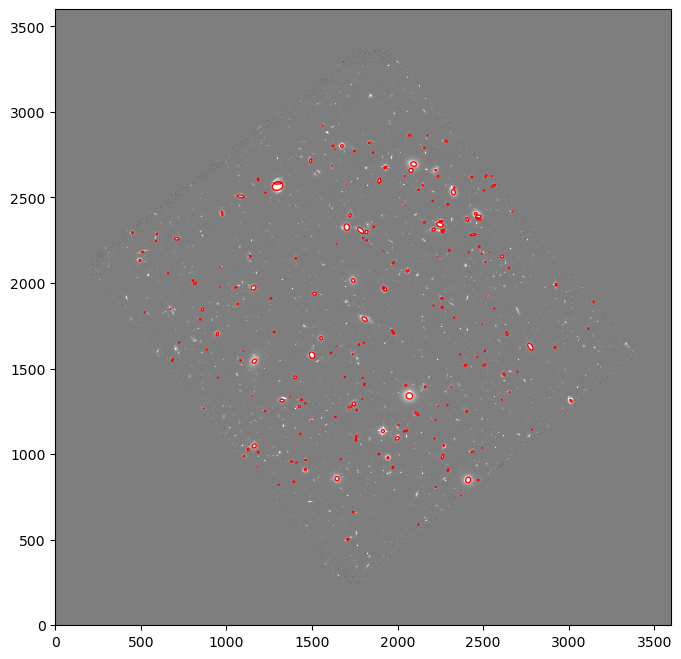

In [73]:
objects = sep.extract(data_sub, 0.0727)
len(objects)
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation = 'nearest', cmap = 'grey', vmin = m-s, vmax = m+s, origin = 'lower')

x = 0
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]), width=6*objects['a'][i], 
                    height=6*objects['b'][i], angle = objects['theta'][i] * 180/np.pi)
    e.set_facecolor("none")
    e.set_edgecolor("red")
    ax.add_artist(e)
    x += 1

print(m,s)
print("Amount of objects: ",x)


In [76]:
flux, fluxer, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 3.0, err = bkg.globalrms, gain = 1.0)

for i in range(10):
    print("objects : {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxer[i]))

print("Mean:", np.mean(flux), "Median: ", np.median(flux), np.std(flux))

objects : 0: flux = 3.217990 +/- 1.793878
objects : 1: flux = 2.246912 +/- 1.498973
objects : 2: flux = 8.213650 +/- 2.865948
objects : 3: flux = 1.923649 +/- 1.386960
objects : 4: flux = 2.079473 +/- 1.442040
objects : 5: flux = 2.305122 +/- 1.518266
objects : 6: flux = 3.387910 +/- 1.840630
objects : 7: flux = 3.308700 +/- 1.818985
objects : 8: flux = 65.683267 +/- 8.104522
objects : 9: flux = 72.440139 +/- 8.511178
Mean: 11.82362953518455 Median:  3.1277742540836337 58.83477215270714


Finish your notebook by answering the following questions, using a combination of text and code directly in the notebook. (Terms like sources and fluxes will gradually become clear as you progress through the tutorial. You are not expected to fully understand all the details.) 
1) How many sources (stars) do you find in the data? Histogram their fluxes.

   There are around 205 sources in the data.
   
3) What are the mean, median, and standard deviation of the distribution of fluxes.

   The mean is 11.8236, the median is 3.1278, and the standard deviation is 58.8348.
   
5) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

   The largest outlier in the distribution is 65.6833, which is about 0.9154 deviations from the mean. 

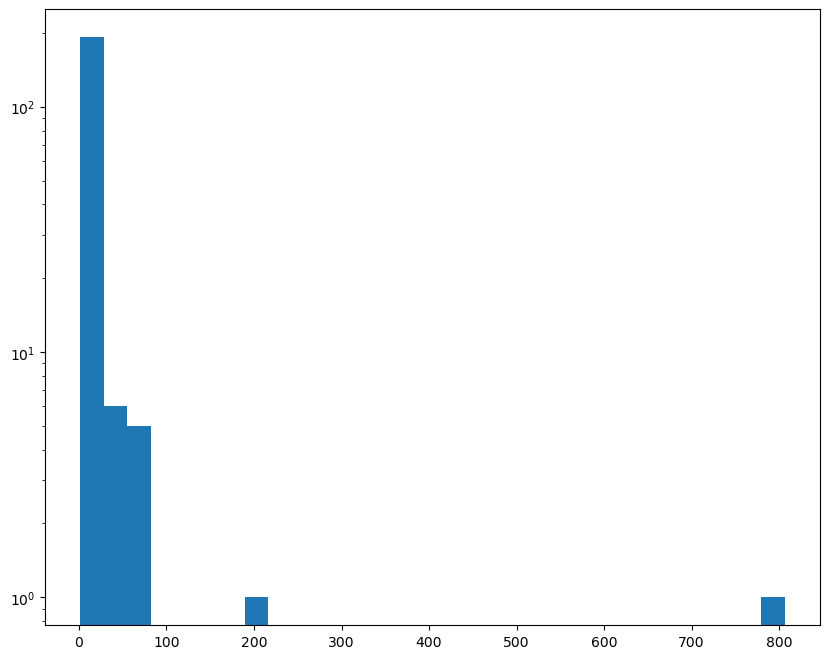

In [108]:
plt.hist(flux, bins = 30)
#plt.xscale('log')
plt.yscale("log")